Contributors: Thomas Asikis, Lucas Bottcher
## Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import torch
from neural_control.controllers import DualFullyConnectedRegressionControllerCompressed, imitatation_learn
from neural_control.dynamics import DualSourcingModel
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from plotly import graph_objects as go
from sourcing_models.utilities import sample_trajectories_capped_dual_index, \
sample_trajectories_dual_index, sample_trajectories_single_index, sample_trajectories_tailored_base_surge
import time

import matplotlib.pyplot as plt
from matplotlib import rcParams
#import seaborn as sns

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

## Sourcing Problem Parameters

In [11]:
sourcing_parameters = dict(ce=20,
                           cr=0,
                           le=0,
                           lr=2,
                           h=5,
                           b=95,
                           T=100)

## NNC Initialization
Here we initialize an NNC model and set  its hyperparameters for training.

In [3]:
### One can experiment with different layer architectures and activations per layer
nnc_hyperparameters = dict(
    n_hidden_units = [64,32,16,8,4]
)

### We use celu non-linearities for the input layer, hidden layers, and output layer
nnc_hyperparameters['n_activations'] = [torch.nn.CELU(alpha=1)]*(2 + len(nnc_hyperparameters['n_hidden_units']))


fcc = DualFullyConnectedRegressionControllerCompressed(lr=sourcing_parameters['lr'], 
                                         le=sourcing_parameters['le'], 
                                         n_hidden_units= nnc_hyperparameters ['n_hidden_units'],
                                         activations=nnc_hyperparameters['n_activations']
                                        ) # controller neural network object


In [4]:
list((k, v.shape) for (k,v) in fcc.named_parameters())

[('layers.0.weight', torch.Size([128, 3])),
 ('layers.0.bias', torch.Size([128])),
 ('layers.1.weight', torch.Size([64, 128])),
 ('layers.1.bias', torch.Size([64])),
 ('layers.2.weight', torch.Size([32, 64])),
 ('layers.2.bias', torch.Size([32])),
 ('layers.3.weight', torch.Size([16, 32])),
 ('layers.3.bias', torch.Size([16])),
 ('layers.4.weight', torch.Size([8, 16])),
 ('layers.4.bias', torch.Size([8])),
 ('layers.5.weight', torch.Size([4, 8])),
 ('layers.5.bias', torch.Size([4])),
 ('layers.6.weight', torch.Size([2, 4])),
 ('layers.6.bias', torch.Size([2]))]

In [5]:
fcc.layers

ModuleList(
  (0): Linear(in_features=3, out_features=128, bias=True)
  (1): Linear(in_features=128, out_features=64, bias=True)
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): Linear(in_features=16, out_features=8, bias=True)
  (5): Linear(in_features=8, out_features=4, bias=True)
  (6): Linear(in_features=4, out_features=2, bias=True)
)

## Dynamics Initialization
To further optimize NNC (''fine tuning''), we now apply gradient propagation to the inventory evolution equation:

$I_t = I_{t-1} + q^{\rm e}_{t-l_{\rm e}} + q^{\rm r}_{t-l_{\rm r}} - D_t$

where $I_0, q^{\rm e}_{t},q^{\rm r}_{t}$ are NNC outputs.

In [12]:
dsd = DualSourcingModel(fcc, I_0=6, **sourcing_parameters) # Dual Sourcing Dynamics object

We preserve the best performing model in training, assuming that the neural network generalizes well during training and that our training sample is large enough.

In [121]:
best_loss = [np.infty]
best_model = [None]

In [122]:
all_training_costs = []

We observe that we have a neural network that outputs $q^{\rm r}_{t-l_{\rm r}}, q^{\rm e}_{t-l_{\rm e}}$ given the input described above.
The initial inventory $I_0$ is independent of inputs and can be learned separately (in a way that is similar to learning a bias term of a neural network).
We use separate optimizers to learn order quantities and initial inventory.
This may create learning variance, as one optimizer may overfit on a value that is directly changed by another optimizer. 
To reduce the learning variance, we let the order optimizer operate on 7 out of 10 learning epochs and the inventory optimizer on the remaining epochs.

In [135]:
optimizer = torch.optim.RMSprop(#[dsd.I_0],
                                list(fcc.parameters()), 
                                lr=1.5e-3
                               )
optimizer2 = torch.optim.RMSprop([dsd.I_0],
                                #list(fcc.parameters()), 
                                lr=1e-2
                               )

We now fine tune the model after imitation, in order to generalize and hopefully outperform the method used to train the model.
To do so, we repetively train and fine tune the parameters of 128 trajectories generated by setting a specific random seed. We do not resample new trajectories, as we want the network to overfit on the process. Sampling new samples could increase the input variance, and could potentially slow/prohibit convergence.

In [147]:
fine_tuning_iterations = 5000
minibatch_size = 512
random_seed = 4

t0 = time.time()
for it in range(fine_tuning_iterations):
    optimizer.zero_grad()
    optimizer2.zero_grad()
    def closure():
        dsd.reset(minibatch_size, seed=random_seed+1)
        total_costs = 0
        for i in range(dsd.T):
            current_costs, demands, current_inventories, qr, qra, qe, qea = dsd.simulate()
            total_costs = current_costs.mean() + total_costs
        all_training_costs.append(float(total_costs)/dsd.T)
        total_costs.backward()
        if it % 20 == 0:
            print(total_costs/dsd.T)
        if total_costs < best_loss[0]:
            best_loss[0] = total_costs.detach().cpu().item()
            best_model[0] = deepcopy(fcc.state_dict())
        return total_costs
    #if it > 1 and all_training_costs[-1] <= 26.4:
    #        break
    if it % 10 > 6:
        optimizer2.step(closure)
    else:
        optimizer.step(closure)
t1 = time.time()
total = t1-t0
print(total)

tensor(23.0943, grad_fn=<DivBackward0>)
tensor(23.0649, grad_fn=<DivBackward0>)
tensor(23.4099, grad_fn=<DivBackward0>)
tensor(23.1333, grad_fn=<DivBackward0>)
tensor(23.0831, grad_fn=<DivBackward0>)
tensor(22.9847, grad_fn=<DivBackward0>)
tensor(23.2403, grad_fn=<DivBackward0>)
tensor(23.4268, grad_fn=<DivBackward0>)
tensor(23.0540, grad_fn=<DivBackward0>)
tensor(23.0047, grad_fn=<DivBackward0>)
tensor(23.1777, grad_fn=<DivBackward0>)
tensor(23.1204, grad_fn=<DivBackward0>)


KeyboardInterrupt: 

<IPython.core.display.Javascript object>


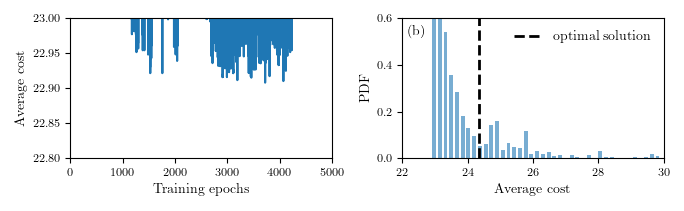

In [148]:
from matplotlib.ticker import NullFormatter

# set nice figure sizes
fig_width_pt = 495    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

costs = np.array(all_training_costs)
#np.savetxt("cost_direct_learning.dat",costs)

fig, ax = plt.subplots(ncols=2)
#ax[0].text(0.02*3000,0.88*(23.5-23)+23,r"(a)")
ax[0].plot(costs,alpha=1)
#ax[0].hlines(25.044,0,9000,linewidths=2,colors="k",linestyles="--")
ax[0].set_xlim(0,5000)
ax[0].set_ylim(22.8,23)
ax[0].yaxis.set_minor_formatter(NullFormatter())
ax[0].set_xlabel(r'Training epochs')
ax[0].set_ylabel(r'Average cost')

ax[1].text(0.02*(30-22)+22,0.88*0.6,r"(b)")
ax[1].hist(costs[costs <= 30],bins=40,density=True,width=0.12,alpha=0.6)
ax[1].vlines(24.33,0,1,linewidths=2,colors="k",linestyles="--",label="optimal solution")
ax[1].set_yticks([0,0.2,0.4,0.6])
ax[1].set_xlabel(r'Average cost')
ax[1].set_ylabel(r'PDF')
ax[1].set_xlim(22,30)
ax[1].set_ylim(0,0.6)
ax[1].legend(loc=1,frameon=False)
plt.tight_layout()
plt.margins(0,0)
plt.savefig("training_dual_index.png", dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)
plt.show()

In [146]:
min(costs)

22.9080078125

The above learning curve can be used to monitor learning.

After successful fine tuning we load the best performing model during training.

In [13]:
best_model_load = torch.load('nnc_best_model_direct_lr=4_ce=10_95_5_Jul2621_64layer_256batch.pt', map_location='cpu')
fcc.load_state_dict(best_model_load)
#fcc.load_state_dict(best_model[0])

<All keys matched successfully>

We often train for $T=50$, but to study the ability of the model to generalize we report the average costs per timestep for $2048$ new samples and $T' = 1000$

In [6]:
fine_tuning_iterations = 1

for it in range(fine_tuning_iterations):

    dsd.reset(1024)
    total_costs = 0
    for i in range(dsd.T*10):
        current_costs, demands, current_inventories, qr, qra, qe, qea = dsd.simulate()
        total_costs = current_costs.mean() + total_costs
    if it % 1 == 0:
        print('Reported mean cost per timestep is: ' + str(total_costs.item()/(dsd.T*10)))

Reported mean cost per timestep is: 23.082296875


In [169]:
#torch.save(best_model[0], 'nnc_best_model_direct_lr=2_ce=20_p=95.pt')

In [151]:
dsd.learned_I_0.detach().clone()[0]

tensor([6.])

## Comparison 
First, we generate new dual-index samples.
These will be used to compare performance on unseen samples for NNC.

In [158]:
sourcing_parameters = dict(ce=20,
                           cr=0,
                           le=0,
                           lr=2,
                           h=5,
                           b=95,
                           T=1000,
                           I0=6)

state_trajectories, qr_trajectories, qe_trajectories =\
    sample_trajectories_capped_dual_index(n_trajectories=20, seed=25, **sourcing_parameters)

minimum cost: 23.066
u1*: 3
u2*: 9
u3*: 3


In [159]:
dsd.reset(1)
def evaluate_nnc_on_sample(state_trajectories, 
                           sample_id):
    
    fixed_demands = state_trajectories[sample_id, 1:, 1].unsqueeze(-1)

    nn_inv = dsd.learned_I_0.detach().clone()
    dsd.reset(1)
    nn_qr = [torch.zeros([1,1])]*(dsd.lr+1)
    nn_qe = [torch.zeros([1,1])]*(dsd.le+1)
    nn_ci = []
    all_nn_inv = [nn_inv.item()]
    D = torch.tensor(0.0).unsqueeze(0).unsqueeze(0)
    for i in range(sourcing_parameters["T"]):
        qr, qe = fcc(D, nn_inv, nn_qr, nn_qe)
        D = fixed_demands[i].unsqueeze(0)
        nn_qr.append(qr)
        nn_qe.append(qe)
        qra = nn_qr[-dsd.lr-1]
        qea = nn_qe[-dsd.le-1]
        c_i, nn_inv = dsd.replay_step(nn_inv, D, qra, qea, qr, qe)
        nn_ci.append(c_i)
        all_nn_inv.append(nn_inv.item())
    return all_nn_inv, nn_qr, nn_qe, nn_ci, torch.stack(nn_ci).mean()

In [160]:
def evaluate_cdi_on_sample(state_trajectories, 
                           qr_trajectories, 
                           qe_trajectories, 
                           sample_id):
    
    dsd.reset(1)
    fixed_demands = state_trajectories[sample_id, 1:, 1].unsqueeze(-1)

    ds_inv = state_trajectories[sample_id, 0, 0].unsqueeze(0).unsqueeze(0)
    dsd.reset(1)
    all_qr = [0]*dsd.lr
    all_qe = [0]*dsd.le
    all_ci = []
    all_inv = [ds_inv.detach().item()]
    for i in range(sourcing_parameters["T"]):
        D = fixed_demands[i].unsqueeze(0)
        if dsd.le == 0:
            qe = qe_trajectories[sample_id, i+1]
        else:
            qe = qe_trajectories[sample_id, dsd.le+i]
    
        if dsd.lr == 0:
            qr = qr_trajectories[sample_id, i+1]
        else:
            qr = qr_trajectories[sample_id, dsd.lr+i]
            
        all_qr.append(qr)
        all_qe.append(qe)
        qra = all_qr[-dsd.lr-1]
        qea = all_qe[-dsd.le-1]
        c_i, ds_inv = dsd.replay_step(ds_inv, D, qra, qea, qr, qe)
        all_inv.append(ds_inv.detach().item())
        all_ci.append(c_i)
    # test if calculated inventories and costs are the same as the ones reported
    # from the dual sourcing code
    assert torch.all(torch.tensor(all_inv) == state_trajectories[sample_id, :, 0])
    assert torch.all(torch.tensor(all_ci) == state_trajectories[sample_id, 1:, -1])
    return all_inv, all_qr, all_qe, all_ci, torch.stack(all_ci).mean()

In [161]:
cost_ratios = []
cost_nn = []
cost_cdi = []

samples = 20
for i in range(samples):
    print("%d/%d samples completed"%(i,samples))
    nn_inv, nn_qr, nn_qe, nn_ci, nn_mean_cost = evaluate_nnc_on_sample(state_trajectories, 
                                                                       i)
    
    cdi_inv, cdi_qr, cdi_qe, cdi_ci, cdi_mean_cost = evaluate_cdi_on_sample(state_trajectories, 
                                                                            qr_trajectories, 
                                                                            qe_trajectories, 
                                                                            i)
    cost_nn.append(nn_mean_cost.detach().item())
    cost_cdi.append(cdi_mean_cost.detach().item())
    cost_ratios.append(nn_mean_cost.detach().item()/cdi_mean_cost.detach().item())

0/20 samples completed
1/20 samples completed
2/20 samples completed
3/20 samples completed
4/20 samples completed
5/20 samples completed
6/20 samples completed
7/20 samples completed
8/20 samples completed
9/20 samples completed
10/20 samples completed
11/20 samples completed
12/20 samples completed
13/20 samples completed
14/20 samples completed
15/20 samples completed
16/20 samples completed
17/20 samples completed
18/20 samples completed
19/20 samples completed


In [162]:
(np.array(cost_ratios) < 1).sum()/len(cost_ratios)

0.55

In [163]:
print(cost_nn[:20],np.mean(cost_nn))
print(cost_cdi[:20],np.mean(cost_cdi))

[22.329999923706055, 22.81999969482422, 23.635000228881836, 21.90999984741211, 21.78499984741211, 22.7549991607666, 23.350000381469727, 22.885000228881836, 23.204999923706055, 22.844999313354492, 23.040000915527344, 23.3700008392334, 22.739999771118164, 22.9950008392334, 23.209999084472656, 23.354999542236328, 22.850000381469727, 23.719999313354492, 22.565000534057617, 23.68000030517578] 22.952250003814697
[22.040000915527344, 23.719999313354492, 23.84000015258789, 21.610000610351562, 22.399999618530273, 22.514999389648438, 23.739999771118164, 22.725000381469727, 22.924999237060547, 23.139999389648438, 23.28499984741211, 23.395000457763672, 22.770000457763672, 23.15999984741211, 23.475000381469727, 23.190000534057617, 22.530000686645508, 23.579999923706055, 22.84000015258789, 23.56999969482422] 23.022500038146973


In [16]:
np.mean(cost_ratios)

0.9859758846914024

Below we plot the distribution of the mean cost per step ratio between NNC and DI.

In [338]:
fig = go.Figure(go.Histogram(x=cost_ratios))
fig.add_vline(x=np.mean(cost_ratios))
fig.layout.xaxis.title = r'$\dfrac{\bar{c}_{\text{NNC}}}{\bar{c}_{\text{Dual Index}}}$'
fig.layout.yaxis.title = 'Count'
fig

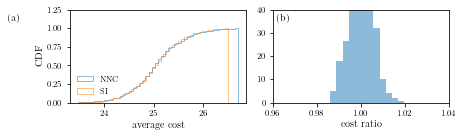

In [671]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 469    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

np.savetxt("nnc_cdi_samples_lr=4_ce=20.dat",np.c_[cost_nn,cost_cdi])

fig, ax = plt.subplots(ncols=2)
ax[0].text(0.02*(24-22)+22,0.88*1.25,r"(a)")
ax[0].hist(cost_nn,alpha=0.5,bins=50,density=True,label=r"NNC",histtype='step',cumulative=True)
ax[0].hist(cost_cdi,alpha=0.5,bins=50,density=True,label=r"SI",histtype='step',cumulative=True)
#ax[0].set_xlim(22,24)
ax[0].set_ylim(0,1.25)
ax[0].set_xlabel(r"average cost")
ax[0].set_ylabel(r"CDF")
ax[0].legend(loc=3,fontsize=8,frameon=False)

ax[1].text(0.02*(1.04-0.96)+0.96,0.88*40,r"(b)")
ax[1].hist(cost_ratios,bins=12,alpha=0.5,density=True)
ax[1].set_xlim(0.96,1.04)
ax[1].set_ylim(0,40)
ax[1].set_xlabel(r"cost ratio")

plt.tight_layout()
plt.margins(0,0)
plt.savefig("cost_comparison_capped_dual_index.png", dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)
plt.show()


## Single sample comparison
Now we compare the 2 models on a single random sample from the above to examine the difference between NNC and DI control trajectories.

In [164]:
fixed_demands = state_trajectories[1, 1:, 1].unsqueeze(-1)
nn_inv, nn_qr, nn_qe, nn_ci, nn_mean_cost = evaluate_nnc_on_sample(state_trajectories, 1)
cdi_inv, cdi_qr, cdi_qe, cdi_ci, cdi_mean_cost = evaluate_cdi_on_sample(state_trajectories, qr_trajectories, qe_trajectories, 1)

In [165]:
a = go.Scatter(y=[x.item() for x in nn_qr[1:]], name='NNC')
b = go.Scatter(y=cdi_qr, name='SI')
fig = go.Figure([a,b])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Regular Order'
fig

In [166]:
print(np.mean([x.item() for x in nn_qr[1:]]),np.std([x.item() for x in nn_qr[1:]]))
print(np.mean(cdi_qr),np.std(cdi_qr))

1.874251497005988 1.1761755442114719
1.8812375249500999 1.1376637060454007


In [167]:
a = go.Scatter(y=[x.item() for x in nn_qe[1:]], name='NNC')
b = go.Scatter(y=cdi_qe, name='SI')
fig = go.Figure([a,b])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Expedited Order'
fig

In [168]:
a = go.Scatter(y=[x.item() for x in nn_ci], name='NNC')
b = go.Scatter(y=[x.item() for x in cdi_ci], name='CDI')
fig = go.Figure([a,b])
fig.add_hline(nn_mean_cost.detach().item())
fig.add_hline(cdi_mean_cost.detach().item(),line={'dash':'dash'})
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Cost'
fig

In [72]:
a = go.Scatter(y=nn_inv, name='NNC Inventory')
b = go.Scatter(y=cdi_inv, name='SI Inventory')
c = go.Scatter(y=[x.detach().item() for x in fixed_demands], name='Demand',
               x=torch.arange(1, 1001).tolist() )
fig = go.Figure([a,b, c])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Quantity'
fig


<IPython.core.display.Javascript object>


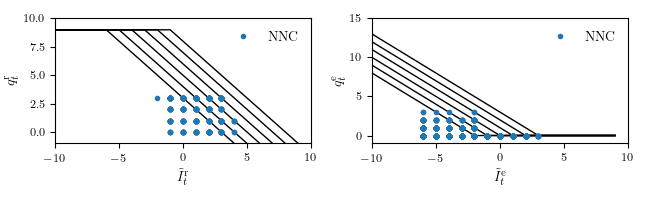

In [82]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 469    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

qr_nnc = np.array([x.item() for x in nn_qr])
qe_nnc = np.array([x.item() for x in nn_qe])
demands = np.array([x.detach().item() for x in fixed_demands])
inventory_nnc = np.array([x for x in nn_inv])

Ipe_nnc = []
Ipr_nnc = []
Ipe_nnc.append(0)
Ipr_nnc.append(0)

for i in range(0,len(demands)):
    
    Ipe_nnc.append(Ipe_nnc[-1]+qe_nnc[dsd.le+1+i]+qr_nnc[dsd.lr+1+i-2]-demands[i])
    Ipr_nnc.append(Ipr_nnc[-1]+qe_nnc[dsd.le+1+i]+qr_nnc[dsd.lr+1+i]-demands[i])

Ipe_nnc = np.array(Ipe_nnc)
Ipr_nnc = np.array(Ipr_nnc)

qte = lambda ze, IPe, qtmlr: max(0,ze-IPe-qtmlr)
qtr = lambda zr, IPr, q: zr-max(0,IPr+q)

IPr_arr = np.arange(-10,10,1)

fix, ax = plt.subplots(ncols=2)

level = 3
for i in range(1,7):
    ax[0].plot(IPr_arr,[qtr(9,x,q=i) for x in IPr_arr], color="k", lw=1)
ax[0].plot(Ipr_nnc[1:][qr_nnc[dsd.lr+1-2:-2]==level],qr_nnc[dsd.lr+1:][qr_nnc[dsd.lr+1-2:-2]==level],marker=".",ls="None", label=r"NNC")

for i in range(1,7):
    ax[1].plot(IPr_arr,[qte(4,x,qtmlr=i) for x in IPr_arr], color="k", lw=1)
ax[1].plot(Ipe_nnc[1:],qe_nnc[dsd.le+1:],marker=".",ls="None", label=r"NNC")
    

ax[0].legend(loc=1,frameon=False)
ax[0].set_xlabel(r"$\tilde{I}_t^{\mathrm{r}}$")
ax[0].set_ylabel(r"$q_t^{\rm r}$")
ax[0].set_xlim(-10,10)
ax[0].set_ylim(-1,10)

ax[1].legend(loc=1,frameon=False)
ax[1].set_xlabel(r"$\tilde{I}_t^{\mathrm{e}}$")
ax[1].set_ylabel(r"$q_t^{\rm e}$")
ax[1].set_xlim(-10,10)
ax[1].set_ylim(-1,15)
plt.tight_layout()
plt.savefig("nnc_di.png", facecolor="white", transparent=False)
plt.show()

<IPython.core.display.Javascript object>


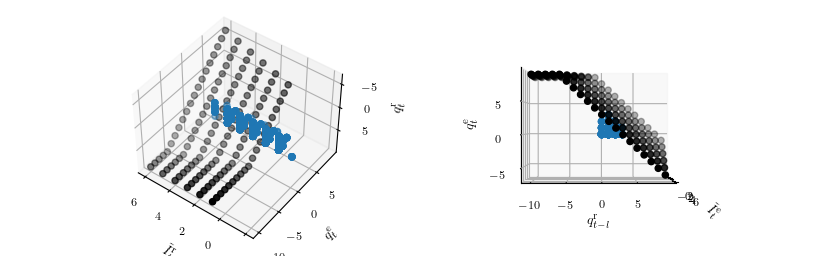

No handles with labels found to put in legend.
No handles with labels found to put in legend.


In [22]:
%matplotlib notebook

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 600    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

from mpl_toolkits.mplot3d import Axes3D
import random


fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

x_ipr = []
y_qtrm2 = []
z_qtr = []

for i in range(1,7):
    for j in IPr_arr:
        x_ipr.append(i)
        y_qtrm2.append(j)
        z_qtr.append(qtr(9,j,q=i))
    
ax1.scatter(x_ipr, y_qtrm2, z_qtr, color="k")
ax1.scatter(Ipr_nnc[1:], qe_nnc[dsd.le+1:], qr_nnc[dsd.lr+1:], color="tab:blue")

x_ipe = []
y_qtem2 = []
z_qte = []

for i in range(1,7):
    for j in IPr_arr:
        x_ipe.append(i)
        y_qtem2.append(j)
        z_qte.append(qte(4,j,qtmlr=i))
    
ax2.scatter(x_ipr, y_qtrm2, z_qtr, color="k")
ax2.scatter(Ipr_nnc[1:], qr_nnc[dsd.lr+1-2:-2], qe_nnc[dsd.le+1:], color="tab:blue")

ax1.set_xlabel(r"$\tilde{I}_t^{\mathrm{r}}$")
ax1.set_ylabel(r"$q_{t}^{\rm e}$")
ax1.set_zlabel(r"$q_t^{\rm r}$")

ax2.set_xlabel(r"$\tilde{I}_t^{\mathrm{e}}$")
ax2.set_ylabel(r"$q_{t-l}^{\rm r}$")
ax2.set_zlabel(r"$q_t^{\rm e}$")

ax1.view_init(-40, 0)
ax2.view_init(-0, 0)

ax1.legend(loc=2,frameon=False)
ax2.legend(loc=2,frameon=False)

plt.tight_layout()
plt.savefig("nnc_di_3d.png", facecolor="white", transparent=False)
plt.show()

In [141]:
for name, param in fcc.named_parameters():
    print(name,param)

layers.0.weight Parameter containing:
tensor([[ 0.0670,  0.0481,  0.5169],
        [-0.1948, -0.5360,  0.5194],
        [ 0.1796,  0.2542,  0.3629],
        [-0.3699,  0.0335,  0.3996],
        [-0.2480,  0.0409, -0.0344],
        [ 0.5358,  0.0524,  0.3866],
        [ 0.1617,  0.2667,  0.2276],
        [-0.3379,  0.1854,  0.2930],
        [-0.0441, -0.4952,  0.3756],
        [-0.1171,  0.0781, -0.0457],
        [-0.1135, -0.1757,  0.1218],
        [-0.0293, -0.6434,  0.3674],
        [-0.4280,  0.2908, -0.1559],
        [-0.0194, -0.7022, -0.2618],
        [-0.3555, -0.0857, -0.0339],
        [-0.2613, -0.4980,  0.2809],
        [-0.0347,  0.0846, -0.1810],
        [-0.0093, -0.5617,  0.1447],
        [-0.6042, -0.2918,  0.4318],
        [ 0.3584,  0.4104, -0.0726],
        [-0.0584, -0.3187,  0.2732],
        [-0.4438,  0.1721,  0.0745],
        [-0.2717, -0.3496,  0.3118],
        [-0.0500, -0.8084, -0.8666],
        [-0.3816,  0.1989, -0.0723],
        [-0.1132, -0.5296,  0.1720],


<IPython.core.display.Javascript object>


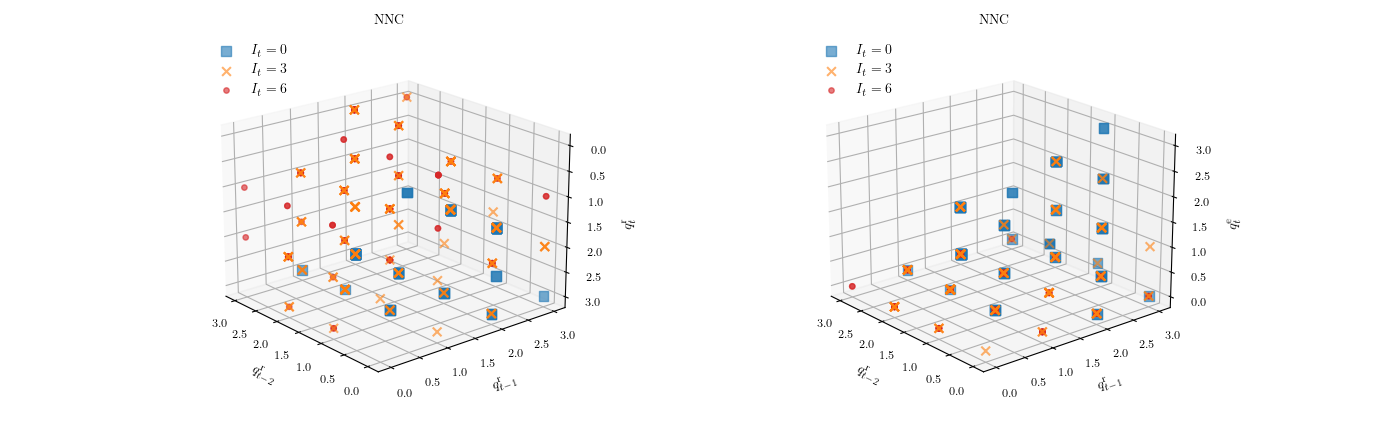

In [23]:
# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 1000    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

ax1.set_title(r"NNC")
ax2.set_title(r"NNC")

level = 0
ax1.scatter(qr_nnc[dsd.lr+1-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr+1-1:-1][inventory_nnc[1:]==level], qr_nnc[dsd.lr+1:][inventory_nnc[1:]==level], color="tab:blue", marker="s", s=50, alpha=0.6, label=r"$I_t=%d$"%level)
ax2.scatter(qr_nnc[dsd.lr+1-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr+1-1:-1][inventory_nnc[1:]==level], qe_nnc[dsd.le+1:][inventory_nnc[1:]==level], color="tab:blue", marker="s", s=50, alpha=0.6, label=r"$I_t=%d$"%level)

level = 3
ax1.scatter(qr_nnc[dsd.lr+1-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr+1-1:-1][inventory_nnc[1:]==level], qr_nnc[dsd.lr+1:][inventory_nnc[1:]==level], color="tab:orange", marker="x", s=40, alpha=0.6, label=r"$I_t=%d$"%level)
ax2.scatter(qr_nnc[dsd.lr+1-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr+1-1:-1][inventory_nnc[1:]==level], qe_nnc[dsd.le+1:][inventory_nnc[1:]==level], color="tab:orange", marker="x", s=40, alpha=0.6, label=r"$I_t=%d$"%level)

level = 6
ax1.scatter(qr_nnc[dsd.lr+1-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr+1-1:-1][inventory_nnc[1:]==level], qr_nnc[dsd.lr+1:][inventory_nnc[1:]==level], color="tab:red", marker="o", s=15, alpha=0.6, label=r"$I_t=%d$"%level)
ax2.scatter(qr_nnc[dsd.lr+1-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr+1-1:-1][inventory_nnc[1:]==level], qe_nnc[dsd.le+1:][inventory_nnc[1:]==level], color="tab:red", marker="o", s=15, alpha=0.6, label=r"$I_t=%d$"%level)



ax1.set_xlabel(r"$q_{t-2}^{\rm r}$")
ax1.set_ylabel(r"$q_{t-1}^{\rm r}$")
ax1.set_zlabel(r"$q_t^{\rm r}$")

ax2.set_xlabel(r"$q_{t-2}^{\rm r}$")
ax2.set_ylabel(r"$q_{t-1}^{\rm r}$")
ax2.set_zlabel(r"$q_t^{\rm e}$")

ax1.view_init(-160, 40)
ax2.view_init(-160, 40)

ax2.invert_zaxis()

ax1.legend(loc=2,frameon=False)
ax2.legend(loc=2,frameon=False)

plt.tight_layout()
plt.savefig("nnc_3d.png", facecolor="white", transparent=False)
plt.show()

<IPython.core.display.Javascript object>


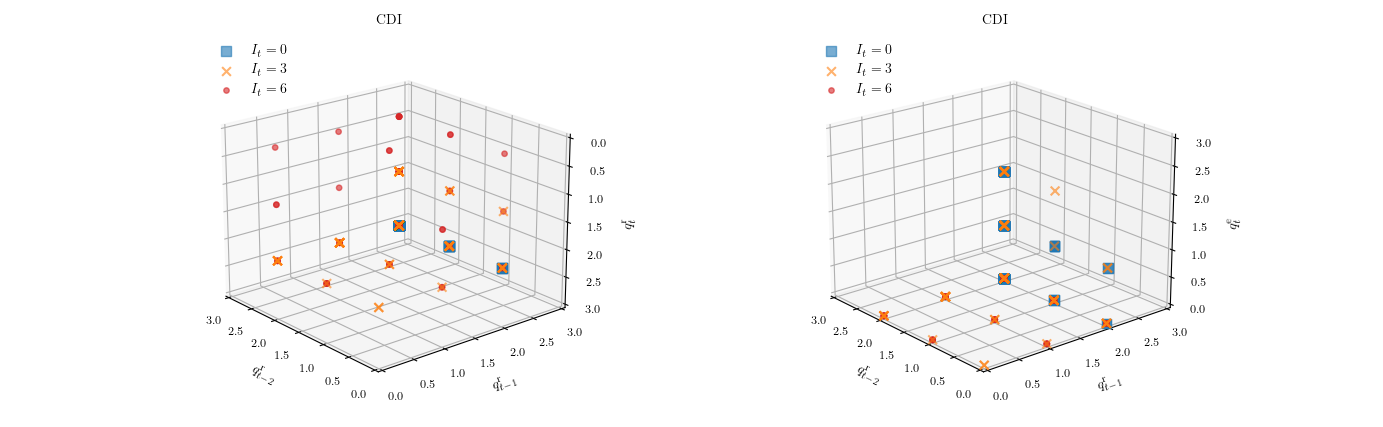

In [24]:
# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 1000    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

qr_nnc = np.array([x for x in cdi_qr])
qe_nnc = np.array([x for x in cdi_qe])
inventory_nnc = np.array([x for x in cdi_inv])

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

ax1.set_title(r"CDI")
ax2.set_title(r"CDI")

level = 0
ax1.scatter(qr_nnc[dsd.lr-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr-1:-1][inventory_nnc[1:]==level], qr_nnc[dsd.lr:][inventory_nnc[1:]==level], color="tab:blue", marker="s", s=50, alpha=0.6, label=r"$I_t=%d$"%level)
ax2.scatter(qr_nnc[dsd.lr-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr-1:-1][inventory_nnc[1:]==level], qe_nnc[dsd.le:][inventory_nnc[1:]==level], color="tab:blue", marker="s", s=50, alpha=0.6, label=r"$I_t=%d$"%level)

level = 3
ax1.scatter(qr_nnc[dsd.lr-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr-1:-1][inventory_nnc[1:]==level], qr_nnc[dsd.lr:][inventory_nnc[1:]==level], color="tab:orange", marker="x", s=40, alpha=0.6, label=r"$I_t=%d$"%level)
ax2.scatter(qr_nnc[dsd.lr-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr-1:-1][inventory_nnc[1:]==level], qe_nnc[dsd.le:][inventory_nnc[1:]==level], color="tab:orange", marker="x", s=40, alpha=0.6, label=r"$I_t=%d$"%level)

level = 6
ax1.scatter(qr_nnc[dsd.lr-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr-1:-1][inventory_nnc[1:]==level], qr_nnc[dsd.lr:][inventory_nnc[1:]==level], color="tab:red", marker="o", s=15, alpha=0.6, label=r"$I_t=%d$"%level)
ax2.scatter(qr_nnc[dsd.lr-2:-2][inventory_nnc[1:]==level], qr_nnc[dsd.lr-1:-1][inventory_nnc[1:]==level], qe_nnc[dsd.le:][inventory_nnc[1:]==level], color="tab:red", marker="o", s=15, alpha=0.6, label=r"$I_t=%d$"%level)



ax1.set_xlabel(r"$q_{t-2}^{\rm r}$")
ax1.set_ylabel(r"$q_{t-1}^{\rm r}$")
ax1.set_zlabel(r"$q_t^{\rm r}$")
ax1.set_xlim(0,3)
ax1.set_ylim(0,3)
ax1.set_zlim(0,3)

ax2.set_xlabel(r"$q_{t-2}^{\rm r}$")
ax2.set_ylabel(r"$q_{t-1}^{\rm r}$")
ax2.set_zlabel(r"$q_t^{\rm e}$")
ax2.set_xlim(0,3)
ax2.set_ylim(0,3)
ax2.set_zlim(0,3)

ax1.view_init(-160, 40)
ax2.view_init(-160, 40)

ax2.invert_zaxis()

ax1.legend(loc=2,frameon=False)
ax2.legend(loc=2,frameon=False)

plt.tight_layout()
plt.savefig("cdi_3d.png", facecolor="white", transparent=False)
plt.show()

In [190]:
qr, qe = fcc(torch.tensor(10.0), torch.tensor([[4.0]]), torch.tensor([[0.0,0.0]]), torch.tensor([[10.0]]))
print(qr.detach().item(),qe.detach().item())

3.0 0.0


In [186]:
inventory_nnc[1:][0], qr_nnc[dsd.lr+1-2:-2][0], qr_nnc[dsd.lr+1-1:-1][0], qe_nnc[dsd.le+1:][0]

(4.0, 0.0, 0.0, 0.0)

In [191]:
qr_nnc[dsd.lr+1:][0]

3.0

<IPython.core.display.Javascript object>


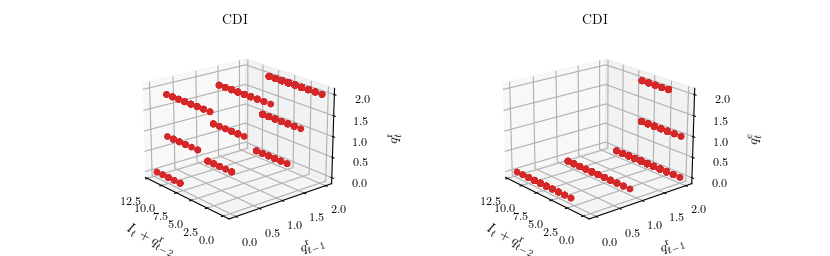

In [57]:
%matplotlib notebook

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 600    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

from mpl_toolkits.mplot3d import Axes3D
import random

qr_cdi = np.array([x for x in cdi_qr])
qe_cdi = np.array([x for x in cdi_qe])
inventory_cdi = np.array([x for x in cdi_inv])

qr_nnc = np.array([x.item() for x in nn_qr])
qe_nnc = np.array([x.item() for x in nn_qe])
inventory_nnc = np.array([x for x in nn_inv])

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

ax1.set_title(r"CDI")
ax2.set_title(r"CDI")

#ax1.scatter(inventory_nnc+qr_nnc[dsd.lr-2:-2], qr_nnc[dsd.lr-1:-1], qr_nnc[dsd.lr:], color="tab:blue", marker="s", zorder=1, s=20, alpha=1)
#ax2.scatter(inventory_nnc+qr_nnc[dsd.lr-2:-2], qr_nnc[dsd.lr-1:-1], qe_nnc[dsd.le:], color="tab:blue", marker="s", zorder=1, s=20, alpha=1)

ax1.scatter(inventory_cdi[1:]+qr_cdi[dsd.lr-2:-2], qr_cdi[dsd.lr-1:-1], qr_cdi[dsd.lr:], color="tab:red", marker="o", zorder=10, s=15, alpha=1)
ax2.scatter(inventory_cdi[1:]+qr_cdi[dsd.lr-2:-2], qr_cdi[dsd.lr-1:-1], qe_cdi[dsd.le:], color="tab:red", marker="o", zorder=10, s=15, alpha=1)

ax1.set_xlabel(r"$I_t+q_{t-2}^{\rm r}$")
ax1.set_ylabel(r"$q_{t-1}^{\rm r}$")
ax1.set_zlabel(r"$q_t^{\rm r}$")

ax2.set_xlabel(r"$I_t+q_{t-2}^{\rm r}$")
ax2.set_ylabel(r"$q_{t-1}^{\rm r}$")
ax2.set_zlabel(r"$q_t^{\rm e}$")

ax1.view_init(-160, 40)
ax2.view_init(-160, 40)

ax1.invert_zaxis()
ax2.invert_zaxis()

plt.tight_layout()
plt.savefig("cdi_3d.png", facecolor="white", transparent=False)
plt.show()

In [170]:
qr_nnc = np.array([x.item() for x in nn_qr])[dsd.lr+1:]
qe_nnc = np.array([x.item() for x in nn_qe])[dsd.le+1:]
demands = np.array([x.detach().item() for x in fixed_demands])
inventory_nnc = np.array([x for x in nn_inv])[:-1]


qr_cdi = np.array([x for x in cdi_qr])[dsd.lr:]
qe_cdi = np.array([x for x in cdi_qe])[dsd.le:]
inventory_cdi = np.array([x for x in cdi_inv])[:-1]

In [171]:
np.savetxt("nnc_cdi_h=%d_b=%d_cr=%d_ce=%d_lr=%d_le=%d_2.csv"%(dsd.h,dsd.b,dsd.cr,dsd.ce,dsd.lr,dsd.le),np.c_[demands,inventory_nnc,qr_nnc,qe_nnc,inventory_cdi,qr_cdi,qe_cdi],delimiter=",",header="demand,nnc inventory, nnc qr, nnc qe, inventory cdi, cdi qr, cdi qe")

In [74]:
demands[:10], inventory_nnc[:10]

(array([2., 3., 4., 4., 0., 0., 1., 2., 4., 0.]),
 array([4., 1., 0., 0., 4., 7., 8., 6., 3., 4.]))

In [75]:
np.array([x for x in nn_inv])

array([6., 4., 1., ..., 2., 5., 6.])

In [76]:
demands[:10]

array([2., 3., 4., 4., 0., 0., 1., 2., 4., 0.])

In [78]:
len(inventory_nnc)

1001

In [79]:
len(demands)

1000

In [107]:
qr, qe = fcc(torch.tensor(10.0), torch.tensor([[8]]), torch.tensor([[0.0,0.0]]), torch.tensor([[10.0]]))
print(qr.detach().item(),qe.detach().item())

1.0 0.0


In [14]:
inv = []
prev_order1 = []
prev_order2 = []

action_qr = []
action_qe = []

for I in range(-8,21):
    for order1 in range(0,7):
        for order2 in range(0,7):
            qr, qe = fcc(torch.tensor(10.0), torch.tensor([[1.0*I]]), torch.tensor([[1.0*order1,1.0*order2]]), torch.tensor([[10.0]]))
            
            action_qr.append(qr.detach().item())
            action_qe.append(qe.detach().item())
            inv.append(I)
            prev_order1.append(order1)
            prev_order2.append(order2)
            
np.savetxt("nnc_actions_h=%d_b=%d_cr=%d_ce=%d_lr=%d_le=%d_compressed.csv"%(dsd.h,dsd.b,dsd.cr,dsd.ce,dsd.lr,dsd.le),np.c_[inv,prev_order1,prev_order2,action_qr,action_qe],fmt="%d,%d,%d,%d,%d",delimiter=",",header="inventory, qr(t-2), qr(t-1), qr(t), qe(t)")